# BERT Model Evaluation

## Objective

The objective of this notebook is to evaluate the BERT classification model on unseen test data.

The evaluation will focus on:

- overall accuracy,
- class-specific precision,
- class-specific recall,
- F1-score,
- confusion matrix,
- and error analysis.

Special attention will be given to the **Suicidal** class because false negatives may have more serious consequences in a mental-health context.

## 1. Import Libraries

Import the libraries required for model loading, prediction, metric calculation, and visualization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "bert_mental_health"

MAX_LENGTH = 128
BATCH_SIZE = 16

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Selected device:", device)

Selected device: mps


## 2. Load the Fine-Tuned Model

Load the fine-tuned BERT model and tokenizer that were saved after validating the training pipeline.

The model will be used to generate predictions on the unseen test dataset.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

model = model.to(device)

model.eval()

print("Model loaded successfully.")
print("Device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully.
Device: mps:0


## 3. Load the Test Dataset

The test dataset contains unseen examples that were never used during training.

It provides an unbiased estimate of the model's generalization performance.

In [4]:
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print(test_df.shape)

test_df.head()

(7341, 2)


,text,status
0,i hate the fact that i m genuinely excited abo...,Normal
1,"Been feeling really suicidal lately, intrusive...",Suicidal
2,bookmark au dong but not read€,Normal
3,artemisiii oh no is it the laundry powder mayb...,Normal
4,"hi everyone, I am a 20 y/o male and I have bee...",Suicidal


## 4. Define Label Mapping

The label mappings are recreated to ensure consistency between
numeric predictions and class names.

In [5]:
label2id = {
    "Anxiety": 0,
    "Depression": 1,
    "Normal": 2,
    "Suicidal": 3,
}

id2label = {value: key for key, value in label2id.items()}

In [6]:
test_df["label"] = test_df["status"].map(label2id)

print(test_df[["status", "label"]].head())
print("Missing labels:", test_df["label"].isna().sum())

     status  label
0    Normal      2
1  Suicidal      3
2    Normal      2
3    Normal      2
4  Suicidal      3
Missing labels: 0


In [7]:
assert test_df["label"].isna().sum() == 0

## 5. Create the Test Dataset

The custom Dataset class converts raw text into tokenized inputs that can be processed by the BERT model.

The same preprocessing pipeline used during training is applied to the test dataset to ensure consistency.

## 5. Custom Dataset Class

The same custom Dataset class is reused to ensure that the test data is processed exactly like the training and validation data.

In [8]:
class MentalHealthDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length: int = 128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = self.df.iloc[index]["text"]
        label = self.df.iloc[index]["label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

In [9]:
test_dataset = MentalHealthDataset(
    dataframe=test_df,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [10]:
batch = next(iter(test_loader))

print(batch.keys())
print("Input IDs:", batch["input_ids"].shape)
print("Attention mask:", batch["attention_mask"].shape)
print("Labels:", batch["labels"].shape)

dict_keys(['input_ids', 'attention_mask', 'labels'])
Input IDs: torch.Size([16, 128])
Attention mask: torch.Size([16, 128])
Labels: torch.Size([16])


## 6. Generate Predictions

The trained BERT model is used to predict labels for the unseen test dataset.

During evaluation, gradients are disabled to reduce memory usage and improve inference speed.

In [11]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1,
        )

        all_predictions.extend(predictions.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

print("Prediction completed.")

print("Number of predictions:", len(all_predictions))

Prediction completed.
Number of predictions: 7341


## 7. Calculate Accuracy

Overall accuracy measures the proportion of correctly classified samples in the test dataset.

Although accuracy is useful, it should not be interpreted alone, especially in healthcare applications.

In [12]:
accuracy = accuracy_score(
    all_labels,
    all_predictions,
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6849


In [13]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Anxiety",
            "Depression",
            "Normal",
            "Suicidal",
        ],
        digits=4,
    )
)

              precision    recall  f1-score   support

     Anxiety     0.6843    0.4693    0.5568       799
  Depression     0.6336    0.4689    0.5390      2139
      Normal     0.8021    0.9438    0.8672      2723
    Suicidal     0.5384    0.6429    0.5860      1680

    accuracy                         0.6849      7341
   macro avg     0.6646    0.6312    0.6372      7341
weighted avg     0.6798    0.6849    0.6734      7341



## 8. Confusion Matrix

The confusion matrix provides a detailed view of the model's predictions by comparing the predicted labels with the true labels.

It helps identify which classes are frequently confused with each other.

In [14]:
cm = confusion_matrix(
    all_labels,
    all_predictions,
)

print(cm)

[[ 375  202  140   82]
 [ 111 1003  255  770]
 [  30   49 2570   74]
 [  32  329  239 1080]]


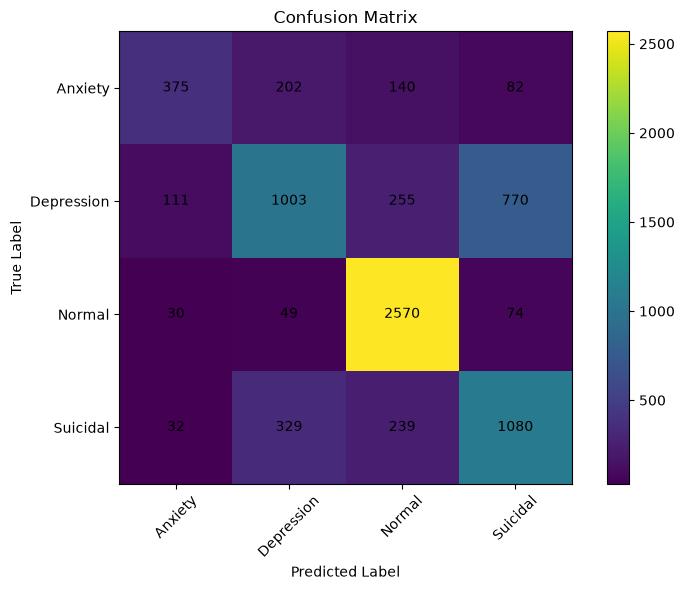

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.colorbar()

classes = [
    "Anxiety",
    "Depression",
    "Normal",
    "Suicidal",
]

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()

## 9. Error Analysis

Model evaluation is not limited to numerical metrics.

Analyzing misclassified examples helps us understand the model's weaknesses and identify opportunities for improvement.

In [16]:
results_df = test_df.copy()

results_df["true_label"] = all_labels
results_df["predicted_label"] = all_predictions

results_df["true_class"] = results_df["true_label"].map(id2label)
results_df["predicted_class"] = results_df["predicted_label"].map(id2label)

results_df.head()

,text,status,label,true_label,predicted_label,true_class,predicted_class
0,i hate the fact that i m genuinely excited abo...,Normal,2,2,2,Normal,Normal
1,"Been feeling really suicidal lately, intrusive...",Suicidal,3,3,3,Suicidal,Suicidal
2,bookmark au dong but not read€,Normal,2,2,2,Normal,Normal
3,artemisiii oh no is it the laundry powder mayb...,Normal,2,2,2,Normal,Normal
4,"hi everyone, I am a 20 y/o male and I have bee...",Suicidal,3,3,3,Suicidal,Suicidal


In [17]:
errors = results_df[results_df["true_label"] != results_df["predicted_label"]]

print("Number of misclassified samples:", len(errors))

Number of misclassified samples: 2313


In [18]:
errors[
    [
        "text",
        "true_class",
        "predicted_class",
    ]
].head(10)

,text,true_class,predicted_class
12,Welcome to todays game of is this anxiety or a...,Anxiety,Normal
13,i’m ready to move out but the city i live in i...,Anxiety,Depression
17,i’m sorry. i know it hurts. i know the pain of...,Anxiety,Depression
20,Realised I'm way more fortunate than most peop...,Normal,Suicidal
21,I should most likely be going to college in Se...,Normal,Suicidal
29,I need such a small trigger and all hell break...,Anxiety,Suicidal
30,"i had just finished college, the teacher had a...",Anxiety,Depression
35,just need someone to talk to whether you re li...,Depression,Normal
38,"Each insult he roared, each that lie he told, ...",Normal,Suicidal
39,Had the opportunity to exchange opinions with ...,Normal,Depression


## 10. Key Takeaways

- The evaluation pipeline successfully generated predictions on unseen data.
- The model achieved reasonable performance on the Normal class.
- The largest source of confusion was between Depression and Suicidal.
- Recall for the Suicidal class remains a critical metric because false negatives may have serious clinical consequences.
- Error analysis suggests that overlapping language patterns contribute to classification errors.

## 11. Future Improvements

Future work may include:

- collecting more high-quality labeled data,
- reviewing potentially ambiguous labels,
- improving text preprocessing,
- performing longer fine-tuning,
- experimenting with different hyperparameters,
- and analyzing additional misclassified examples.

# 12. Conclusions

This notebook evaluated the fine-tuned BERT model on an unseen test dataset.

Key findings include:

- The evaluation pipeline successfully generated predictions for all test samples.
- The model achieved the strongest performance on the Normal class.
- The largest source of confusion occurred between the Depression and Suicidal classes.
- This confusion is understandable because these classes may share similar linguistic patterns.
- In mental health applications, recall for the Suicidal class is especially important because false negatives may have serious clinical consequences.

Overall, this notebook demonstrates a complete evaluation workflow including prediction, performance metrics, confusion matrix analysis, and error analysis.

# Reflection

This evaluation highlighted that building a machine learning model is only one part of the workflow.

Understanding model errors is equally important.

The confusion matrix and misclassified examples provide valuable insights for future improvements.

Future work will focus on improving the discrimination between Depression and Suicidal texts through better data quality, additional training, and further experimentation.

> **Note:** The evaluation results presented in this notebook are based on the initial fine-tuned checkpoint used to validate the training pipeline. Additional experiments with longer fine-tuning and hyperparameter optimization will be presented in Notebook 06. 